                                                     Training of Recurrent Neural Networks (RNN) in TensorFlow                            


## Training of Recurrent Neural Networks (RNN) in TensorFlow

Recurrent Neural Networks (RNNs) are a type of neural network designed to handle sequential data. They maintain hidden states that capture information from previous steps. In this article we will be learning to implement RNN model using TenserFlow.

Here we will be using a clothing brands reviews as dataset and will be using RNN to analyze there reviews.

### 1. Importing Libraries

In [5]:
import warnings
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

import re
import nltk
nltk.download('all')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemm = WordNetLemmatizer()

warnings.filterwarnings("ignore")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to C:\Users\PANDIT
[nltk_data]    |     JI\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to C:\Users\PANDIT
[nltk_data]    |     JI\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\PANDIT JI\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\PANDIT JI\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\PANDIT JI\AppData\Ro

### 2. Loading the Dataset

In [6]:
Dataset = "https://raw.githubusercontent.com/itsluckysharma01/Datasets/refs/heads/main/RNN_Clothing-Review.csv"

df = pd.read_csv(Dataset)
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [7]:
df.shape

(23486, 10)

### 3. Performing Exploratory Data Analysis

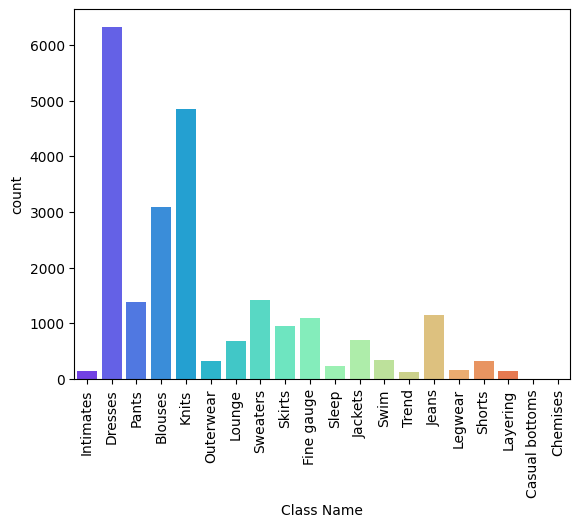

In [8]:
sns.countplot(data=df, x="Class Name", palette="rainbow")
plt.xticks(rotation=90)
plt.show()

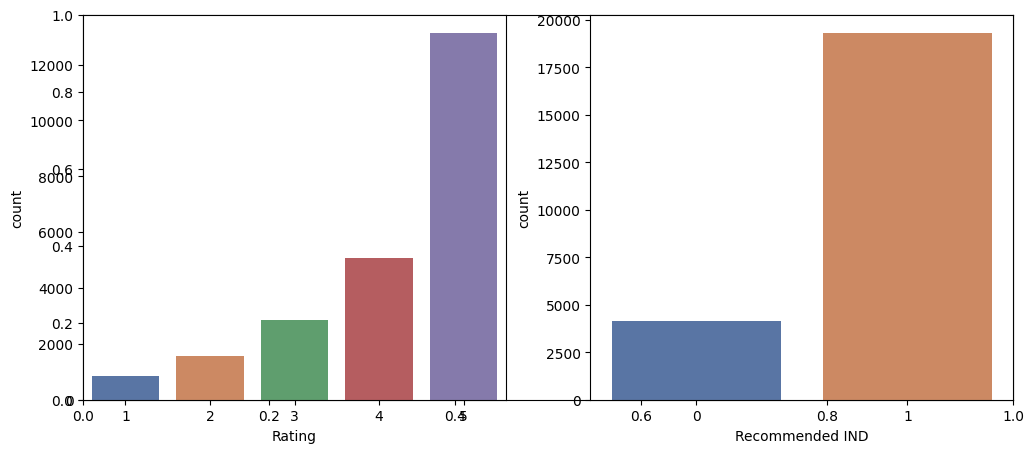

In [9]:
plt.subplots(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Rating',palette="deep")

plt.subplot(1, 2, 2)
sns.countplot(data=df, x="Recommended IND", palette="deep")
plt.show()

In [10]:
fig = px.histogram(df, marginal='box',
                   x="Age", title="Age Group",
                   color="Recommended IND",
                   nbins=65-18,
                   color_discrete_sequence=['green', 'red'])
fig.update_layout(bargap=0.2)

The histogram on the bottom shows age distribution with green bars for recommended individuals and red bars for non-recommended ones. The box plots at the top display the spread and outliers of ages for each recommendation group helping to visualize differences in age distribution between the two groups.

We can visualize the distribution of the age columns data along with the Rating.

In [11]:
fig = px.histogram(df,
                   x="Age",
                   marginal='box',
                   title="Age Group",
                   color="Rating",
                   nbins=65-18,
                   color_discrete_sequence
                   =['black', 'green', 'blue', 'red', 'yellow'])
fig.update_layout(bargap=0.2)

The histogram at the bottom represents the count of individuals in each age group with bars color coded by rating from 1 to 5. The boxplots at the top provide a summary of age distribution for each rating showing the median, interquartile range and outliers. It helps to analyze how ratings vary with age groups.

### 4. Prepare the Data to build Model

Since we are working on the NLP-based dataset it could be valid to use Text columns as the feature. So we select the features that are text and the Rating column is used for Sentiment Analysis. By the above Rating counterplot we can observe that there is too much of an imbalance between the rating. So all the rating above 3 is made as 1 and below 3 as 0. 

In [12]:
df.head(2)

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses


In [13]:
def filter_score(rating):
    return int(rating > 3)

features = ['Class Name', 'Title', 'Review Text']

X = df[features]
y = df['Rating']
y = y.apply(filter_score)

### 5. Text Preprocessing

The text data we have comes with too much noise. This noise can be in form of repeated words or commonly used sentences. In text preprocessing we need the text in the same format so we first convert the entire text into lowercase and then perform Lemmatization to remove the superposition of the words. Since we need clean text we also remove common words such as Stopwords and punctuation. 

In [14]:
def toLower(data):
    if isinstance(data, float):
        return '<UNK>'
    else:
        return data.lower()

stop_words = stopwords.words("english")

def remove_stopwords(text):
    no_stop = []
    for word in text.split(' '):
        if word not in stop_words:
            no_stop.append(word)
    return " ".join(no_stop)

def remove_punctuation_func(text):
    return re.sub(r'[^a-zA-Z0-9]', ' ', text)

X['Title'] = X['Title'].apply(toLower)
X['Review Text'] = X['Review Text'].apply(toLower)

X['Title'] = X['Title'].apply(remove_stopwords)
X['Review Text'] = X['Review Text'].apply(remove_stopwords)

X['Title'] = X['Title'].apply(lambda x: lemm.lemmatize(x))
X['Review Text'] = X['Review Text'].apply(lambda x: lemm.lemmatize(x))

X['Title'] = X['Title'].apply(remove_punctuation_func)
X['Review Text'] = X['Review Text'].apply(remove_punctuation_func)

X['Text'] = list(X['Title']+X['Review Text']+X['Class Name'])


X_train, X_test, y_train, y_test = train_test_split(
    X['Text'], y, test_size=0.25, random_state=42)

### 6. Tokenization

In Tokenization we convert the text into Vectors. Keras API supports text pre-processing. This API consists of Tokenizer that takes in the total num_words to create the Word index. OOV stands for out of vocabulary this is triggered when new text is encountered.  Also remember that we fit_on_texts only on training data and not testing. 

**Vectors are numeric representation of data so that machine can easily be understand and use it for training.**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


In [27]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

# Remove NaN values from X_train before tokenization
X_train_clean = X_train.fillna('').astype(str)

# Remove empty strings and align y_train accordingly
mask = X_train_clean.str.len() > 0
X_train_clean = X_train_clean[mask]
y_train_clean = y_train[mask]

tokenizer.fit_on_texts(X_train_clean)

### 7. Padding the Text Data

Keras preprocessing helps in organizing the text. Padding helps in building models of the same size that further becomes easy to train neural network models. The padding adds extra zeros to satisfy the maximum length to feed a neural network. If the text length exceeds then it can be truncated from either the beginning or end. By default it is pre, we can set it to post or leave it as it is.

In [28]:
train_seq = tokenizer.texts_to_sequences(X_train_clean)

# Clean X_test the same way as X_train
X_test_clean = X_test.fillna('').astype(str)
mask_test = X_test_clean.str.len() > 0
X_test_clean = X_test_clean[mask_test]
y_test_clean = y_test[mask_test]

test_seq = tokenizer.texts_to_sequences(X_test_clean)

train_pad = pad_sequences(train_seq,
                          maxlen=40,
                          truncating="post",
                          padding="post")
test_pad = pad_sequences(test_seq,
                         maxlen=40,
                         truncating="post",
                         padding="post")

### 8. Building a Recurrent Neural Network (RNN) in TensorFlow


In [25]:
from tensorflow import keras

model = keras.models.Sequential()
model.add(keras.layers.Embedding(input_dim=10000, output_dim=128, input_length=40))
model.add(keras.layers.SimpleRNN(64, return_sequences=True))
model.add(keras.layers.SimpleRNN(64))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(1, activation="sigmoid"))

model.build(input_shape=(None, 40))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 40, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,309,057 (4.99 MB)

 Trainable params: 1,309,057 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

### 9. Training the Model

In [29]:
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
              

history = model.fit(train_pad,
                    y_train_clean,
                    epochs=5)

Epoch 1/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7692 - loss: 0.5262
Epoch 2/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8142 - loss: 0.4046
Epoch 3/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.8465 - loss: 0.3531
Epoch 4/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.8984 - loss: 0.2626
Epoch 5/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.9118 - loss: 0.2255


Here we can see our model got a accuracy of 91% which is pretty good for a RNN model.